# BTCUSDT 1-Minute Data Quality Check

This notebook performs thesis-ready exploratory validation for the processed BTCUSDT 1-minute dataset. It checks schema integrity, missing values, temporal continuity, and key stylized behaviors (price path, returns, volatility, and return distribution).

## 1. Setup and Data Loading

This section resolves project paths, loads processed parquet, and confirms that expected files are available.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / 'src').exists():
    project_root = project_root.parent

processed_path = project_root / 'data' / 'processed' / 'crypto' / '1min' / 'BTCUSDT_1m_processed.parquet'
missing_diag_path = project_root / 'data' / 'metadata' / 'BTCUSDT_1m_missing_timestamps.csv'

print(f'Project root: {project_root}')
print(f'Processed file exists: {processed_path.exists()}')
print(f'Missing diagnostics exists: {missing_diag_path.exists()}')

df = pd.read_parquet(processed_path)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.sort_values('timestamp').reset_index(drop=True)
df.head()

Project root: c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis
Processed file exists: True
Missing diagnostics exists: True


,timestamp,open,high,low,close,volume,log_return,pct_return,volatility_30m,volatility_60m,volatility_240m,realized_volatility_60m
0,2017-08-17 04:00:00+00:00,4261.48,4261.48,4261.48,4261.48,1.775183,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-08-17 04:01:00+00:00,4261.48,4261.48,4261.48,4261.48,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
2,2017-08-17 04:02:00+00:00,4280.56,4280.56,4280.56,4280.56,0.261074,0.004467,0.004477,NaN,NaN,NaN,NaN
3,2017-08-17 04:03:00+00:00,4261.48,4261.48,4261.48,4261.48,0.012008,-0.004467,-0.004457,NaN,NaN,NaN,NaN
4,2017-08-17 04:04:00+00:00,4261.48,4261.48,4261.48,4261.48,0.140796,0.000000,0.000000,NaN,NaN,NaN,NaN


## 2. Structural Summary

We inspect head/tail, data types, missing-value counts, and global date range to validate the processed dataset structure before downstream motif experiments.

### Features

| Feature                     | Formula                                                       | Components Breakdown                                                                    | Interpretation                     |
| --------------------------- | ------------------------------------------------------------- | --------------------------------------------------------------------------------------- | ---------------------------------- |
| **close**                   | $( P_t )$                                                       | $(P_t)$: price at time $(t)$                                                                | Absolute market level              |
| **log_return**              | $( \log\left(\frac{P_t}{P_{t-1}}\right) )$                      | $(P_t)$: current price<br>$(P_{t-1})$: previous price                                       | Relative change (additive, stable) |
| **pct_return**              | $( \frac{P_t - P_{t-1}}{P_{t-1}} )$                             | numerator: price change<br>denominator: previous price                                  | Percentage change                  |
| **volatility_Nm**           | $( \sqrt{\frac{1}{N} \sum_{i=0}^{N-1} (r_{t-i} - \bar{r})^2} )$ | $(r_t)$: log return<br>$(\bar{r})$: mean return over window<br>$(N)$: window size (30,60,240) | Dispersion (market noise level)    |
| **realized_volatility_60m** | $( \sqrt{\sum_{i=0}^{59} r_{t-i}^2} )$                          | $(r_t)$: log return<br>No mean subtraction                                                | Total movement energy              |


In [2]:
display(df.head(3))
display(df.tail(3))

dtype_summary = df.dtypes.astype(str).rename('dtype').to_frame()
missing_summary = df.isna().sum().rename('missing_count').to_frame()

display(dtype_summary)
display(missing_summary)

date_min = df['timestamp'].min()
date_max = df['timestamp'].max()
row_count = len(df)

print(f'Row count: {row_count:,}')
print(f'Date range (UTC): {date_min} -> {date_max}')

,timestamp,open,high,low,close,volume,log_return,pct_return,volatility_30m,volatility_60m,volatility_240m,realized_volatility_60m
0,2017-08-17 04:00:00+00:00,4261.48,4261.48,4261.48,4261.48,1.775183,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-08-17 04:01:00+00:00,4261.48,4261.48,4261.48,4261.48,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
2,2017-08-17 04:02:00+00:00,4280.56,4280.56,4280.56,4280.56,0.261074,0.004467,0.004477,NaN,NaN,NaN,NaN


,timestamp,open,high,low,close,volume,log_return,pct_return,volatility_30m,volatility_60m,volatility_240m,realized_volatility_60m
4502645,2026-03-15 23:57:00+00:00,72778.66,72787.33,72762.14,72785.39,4.86794,0.000093,0.000093,0.000712,0.000893,0.00083,0.006862
4502646,2026-03-15 23:58:00+00:00,72785.40,72816.88,72785.39,72794.20,15.23429,0.000121,0.000121,0.000711,0.000877,0.00083,0.006734
4502647,2026-03-15 23:59:00+00:00,72794.20,72824.00,72789.34,72815.24,32.40847,0.000289,0.000289,0.000663,0.000873,0.00083,0.006710


,dtype
timestamp,"datetime64[ms, UTC]"
open,float64
high,float64
low,float64
close,float64
volume,float64
log_return,float64
pct_return,float64
volatility_30m,float64
volatility_60m,float64


,missing_count
timestamp,0
open,0
high,0
low,0
close,0
volume,0
log_return,1
pct_return,1
volatility_30m,30
volatility_60m,60


Row count: 4,502,648
Date range (UTC): 2017-08-17 04:00:00+00:00 -> 2026-03-15 23:59:00+00:00


## 3. Price Series Behavior

Plotting close prices helps verify data continuity and identifies obvious anomalies (flatlines, spikes, truncations).

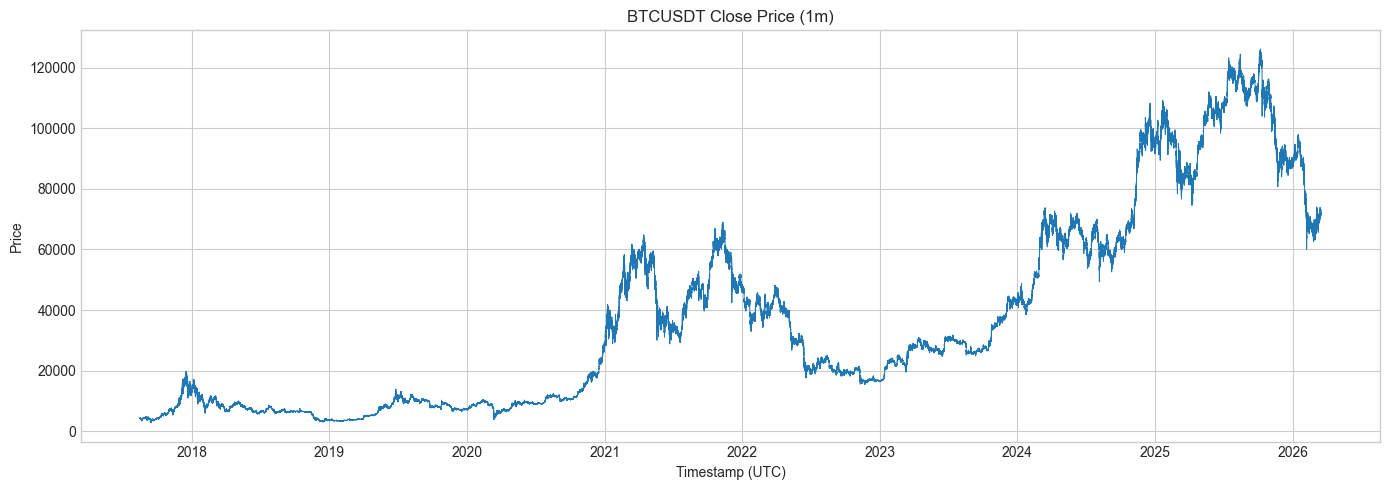

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['timestamp'], df['close'], linewidth=0.7, color='tab:blue')
ax.set_title('BTCUSDT Close Price (1m)')
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Price')
plt.tight_layout()
plt.show()

## 4. Return Dynamics

Log returns should fluctuate around zero with volatility clustering; this plot is a quick sanity check before motif mining and regime conditioning.

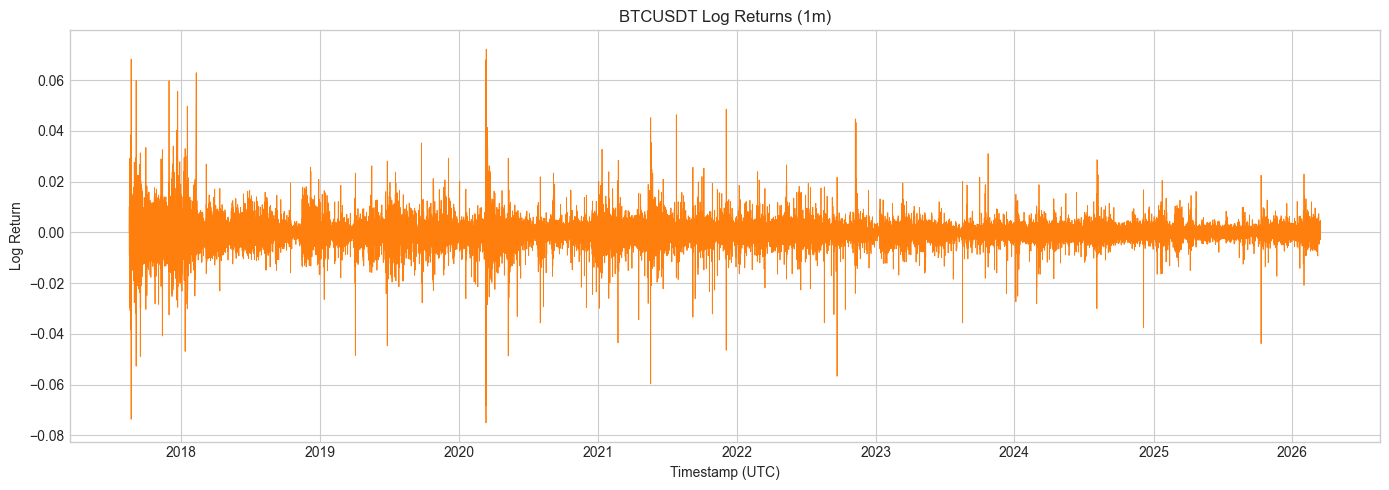

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['timestamp'], df['log_return'], linewidth=0.6, color='tab:orange')
ax.set_title('BTCUSDT Log Returns (1m)')
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Log Return')
plt.tight_layout()
plt.show()

## 5. Rolling Volatility Features

We visualize engineered rolling volatility features to verify expected scale and time variation.

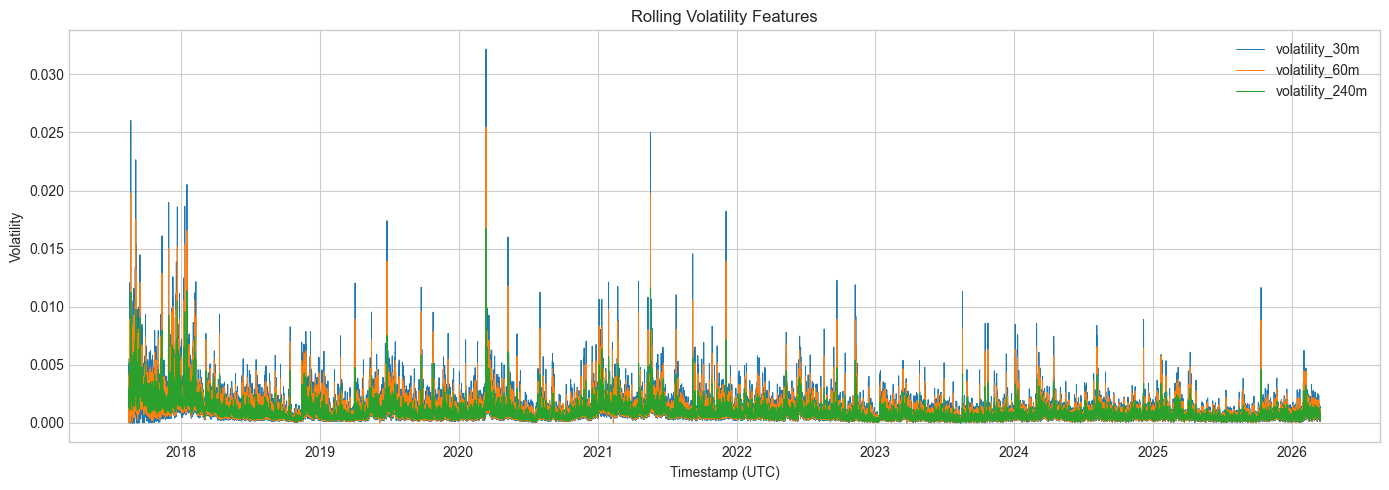

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['timestamp'], df['volatility_30m'], label='volatility_30m', linewidth=0.7)
ax.plot(df['timestamp'], df['volatility_60m'], label='volatility_60m', linewidth=0.7)
ax.plot(df['timestamp'], df['volatility_240m'], label='volatility_240m', linewidth=0.8)
ax.set_title('Rolling Volatility Features')
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Volatility')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Return Distribution

A histogram of log returns supports quick checks of heavy tails and potential outliers relevant for motif robustness analysis.

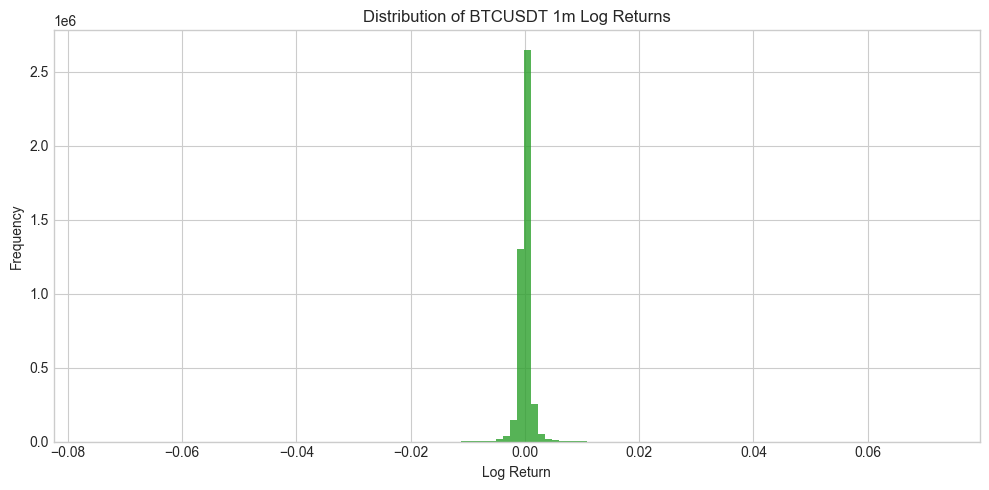

Return summary:


count    4.502647e+06
mean     6.303645e-07
std      1.142905e-03
min     -7.510582e-02
1%      -3.215141e-03
5%      -1.364432e-03
50%      0.000000e+00
95%      1.368455e-03
99%      3.214440e-03
max      7.229275e-02
Name: log_return, dtype: float64

In [6]:
returns = df['log_return'].dropna()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(returns, bins=120, color='tab:green', alpha=0.8)
ax.set_title('Distribution of BTCUSDT 1m Log Returns')
ax.set_xlabel('Log Return')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Return summary:')
display(returns.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

## 7. Missing Timestamp Diagnostics

This section checks explicit missing timestamp diagnostics from pipeline metadata and recomputes an in-notebook missing-bar count for cross-validation.

In [7]:
if missing_diag_path.exists():
    missing_df = pd.read_csv(missing_diag_path)
    print(f'Missing timestamps reported by pipeline: {len(missing_df):,}')
    display(missing_df.head(10))
else:
    print('Missing timestamp diagnostics CSV not found.')

expected_range = pd.date_range(df['timestamp'].min(), df['timestamp'].max(), freq='1min', tz='UTC')
observed = pd.DatetimeIndex(df['timestamp'])
missing_recomputed = expected_range.difference(observed)

print(f'Recomputed missing timestamps: {len(missing_recomputed):,}')
if len(missing_recomputed) > 0:
    display(pd.DataFrame({'timestamp': missing_recomputed[:10]}))

Missing timestamps reported by pipeline: 8,632


,timestamp
0,2017-09-06 16:01:00+00:00
1,2017-09-06 16:02:00+00:00
2,2017-09-06 16:03:00+00:00
3,2017-09-06 16:04:00+00:00
4,2017-09-06 16:05:00+00:00
5,2017-09-06 16:06:00+00:00
6,2017-09-06 16:07:00+00:00
7,2017-09-06 16:08:00+00:00
8,2017-09-06 16:09:00+00:00
9,2017-09-06 16:10:00+00:00


Recomputed missing timestamps: 8,632


,timestamp
0,2017-09-06 16:01:00+00:00
1,2017-09-06 16:02:00+00:00
2,2017-09-06 16:03:00+00:00
3,2017-09-06 16:04:00+00:00
4,2017-09-06 16:05:00+00:00
5,2017-09-06 16:06:00+00:00
6,2017-09-06 16:07:00+00:00
7,2017-09-06 16:08:00+00:00
8,2017-09-06 16:09:00+00:00
9,2017-09-06 16:10:00+00:00


## 8. Interpretation Notes for Thesis Workflow

- Initial NaNs in return/volatility columns are expected from differencing and rolling windows.
- Any non-zero missing-bar count should be handled explicitly before motif benchmarking.
- These diagnostics should be rerun after every raw data refresh to preserve reproducibility.